In [ ]:
import pytensor as pt

import numpy as np
# pt.config.compute_test_value = 'off'
# pt.config.optimizer = 'None'

In [ ]:
from probrisk.utils.data import load_data1

In [ ]:
df = load_data1()

In [24]:
df = df.xs('description', level='COND')
df['choice'] = df['response']

In [25]:
df['response'].mean()

0.32525050100200403

In [29]:
from bauer.models import RiskModelProbabilityDistortion

In [30]:
model = RiskModelProbabilityDistortion(df)

In [31]:
model.build_estimation_model()

{'n1_evidence_mu': log(n1), 'p1_evidence_mu': p1, 'n1_evidence_sd': Scalar_softplus.0, 'p1_evidence_sd': Scalar_softplus.0, 'n1_prior_mu': mean, 'p1_prior_mu': AdvancedSubtensor.0, 'n1_prior_sd': Scalar_softplus.0, 'p1_prior_sd': Scalar_softplus.0, 'n2_evidence_mu': log(n2), 'p2_evidence_mu': p2, 'n2_evidence_sd': Scalar_softplus.0, 'p2_evidence_sd': Scalar_softplus.0, 'n2_prior_mu': mean, 'p2_prior_mu': AdvancedSubtensor.0, 'n2_prior_sd': Scalar_softplus.0, 'p2_prior_sd': Scalar_softplus.0}
p1_posterior_mu [4990]
p1_posterior_sd [4990]
p2_posterior_mu [4990]
p2_posterior_sd [4990]
p_posterior1 [4990   20]
p_posterior2 [4990   20]
p_posterior_joint [4990   20   20]
ev1_hat_mean [4990   20]
ev_diff_mean [4990   20   20]
ev_diff_sd [4990]
p_choice [4990   20   20]
p_choice [4990]


In [32]:
import pytensor.tensor as pt
import numpy as np

In [35]:
idata = model.sample(200, 200)

Only 200 samples in chain.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [probability_evidence_sd_mu_untransformed, probability_evidence_sd_sd, probability_evidence_sd_offset, magnitude_evidence_sd_mu_untransformed, magnitude_evidence_sd_sd, magnitude_evidence_sd_offset, probability_prior_mu_mu, probability_prior_mu_sd, probability_prior_mu_offset, magnitude_prior_sd_mu_untransformed, magnitude_prior_sd_sd, magnitude_prior_sd_offset, probability_prior_sd_mu_untransformed, probability_prior_sd_sd, probability_prior_sd_offset]


Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 79792 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
There were 218 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


In [20]:
iata.posterior

NameError: name 'iata' is not defined

In [19]:
sns.distplot(idata.posterior['probability_prior_mu_mu'])

KeyError: 'probability_prior_mu_mu'

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_29972/1643802905.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(idata.posterior['probability_evidence_sd_mu'])
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_29972/1643802905.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.di

<Axes: xlabel='probability_prior_sd_mu', ylabel='Density'>

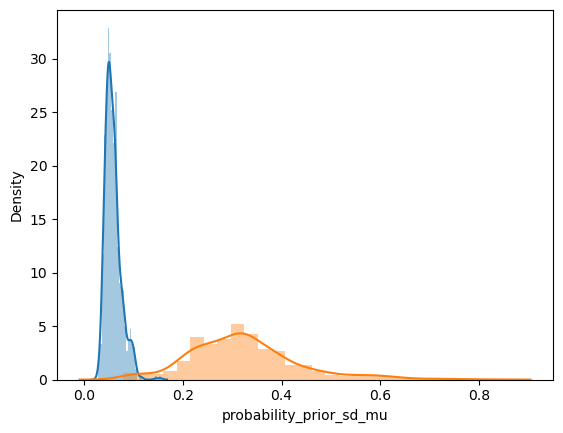

In [ ]:
sns.distplot(idata.posterior['probability_evidence_sd_mu'])
sns.distplot(idata.posterior['probability_prior_sd_mu'])

In [ ]:
idata.constant_data['choice'].mean()

<xarray.DataArray 'choice' ()>
array(0.23068894)

In [ ]:
idata.posterior['probability_evidence_sd'].to_dataframe()

probability_evidence_sd
chain draw subject                         
0     0    1                       0.090669
           2                       0.069802
           3                       0.070862
           4                       0.071967
           5                       0.080949
...                                     ...
3     199  6                       0.040145
           7                       0.075028
           8                       0.078582
           9                       0.074336
           10                      0.058991

[8000 rows x 1 columns]

In [ ]:
sns.catplot(x='subject', y='magnitude_evidence_sd', data=idata.posterior['probability_evidence_sd'].to_dataframe().reset_index(), aspect=3, kind='violin')

ValueError: Could not interpret input 'magnitude_evidence_sd'

In [ ]:
idata.posterior

<xarray.Dataset>
Dimensions:                                   (chain: 4, draw: 200,
                                               subject: 10, p_dist1_dim_0: 958,
                                               p_dist1_dim_1: 20,
                                               p_dist2_dim_0: 958,
                                               p_dist2_dim_1: 20, p_dim_0: 958)
Coordinates:
  * chain                                     (chain) int64 0 1 2 3
  * draw                                      (draw) int64 0 1 2 ... 197 198 199
  * subject                                   (subject) int64 1 2 3 4 ... 8 9 10
  * p_dist1_dim_0                             (p_dist1_dim_0) int64 0 1 ... 957
  * p_dist1_dim_1                             (p_dist1_dim_1) int64 0 1 ... 19
  * p_dist2_dim_0                             (p_dist2_dim_0) int64 0 1 ... 957
  * p_dist2_dim_1                             (p_dist2_dim_1) int64 0 1 ... 19
  * p_dim_0                                   (p_dim_0) int64 0 1 2 ... 956 957
Data variables: (12/31)
    probability_evidence_sd_mu_untransformed  (chain, draw) float64 -2.552 .....
    probability_evidence_sd_offset            (chain, draw, subject) float64 ...
    magnitude_evidence_sd_mu_untransformed    (chain, draw) float64 -1.88 ......
    magnitude_evidence_sd_offset              (chain, draw, subject) float64 ...
    probability_prior_mu_mu                   (chain, draw) float64 0.2507 .....
    probability_prior_mu_offset               (chain, draw, subject) float64 ...
    ...                                        ...
    probability_prior_sd_mu                   (chain, draw) float64 0.09498 ....
    probability_prior_sd_untransformed        (chain, draw, subject) float64 ...
    probability_prior_sd                      (chain, draw, subject) float64 ...
    p_dist1                                   (chain, draw, p_dist1_dim_0, p_dist1_dim_1) float64 ...
    p_dist2                                   (chain, draw, p_dist2_dim_0, p_dist2_dim_1) float64 ...
    p                                         (chain, draw, p_dim_0) float64 ...
Attributes:
    created_at:                 2023-11-20T10:46:55.077011
    arviz_version:              0.14.0
    inference_library:          pymc
    inference_library_version:  5.7.0
    sampling_time:              1896.6057999134064
    tuning_steps:               200

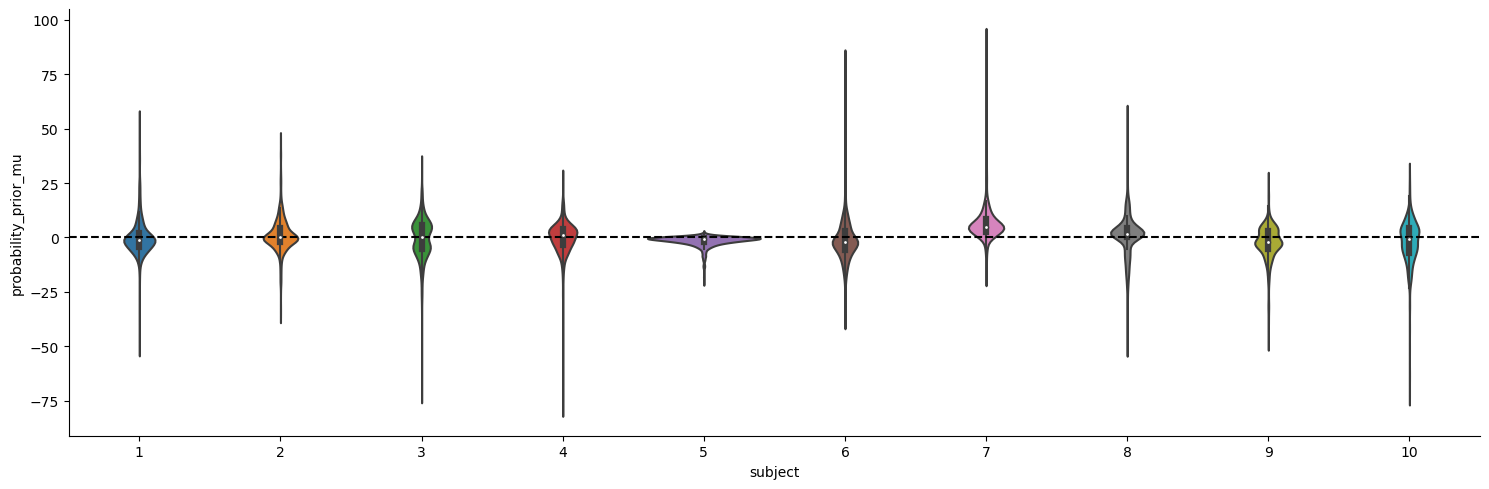

In [ ]:
import matplotlib.pyplot as plt
sns.catplot(x='subject', y='probability_prior_mu', data=idata.posterior['probability_prior_mu'].to_dataframe().reset_index(), aspect=3, kind='violin')
# plt.ylim(0, 2)
plt.axhline(0.0, c='k', ls='--')

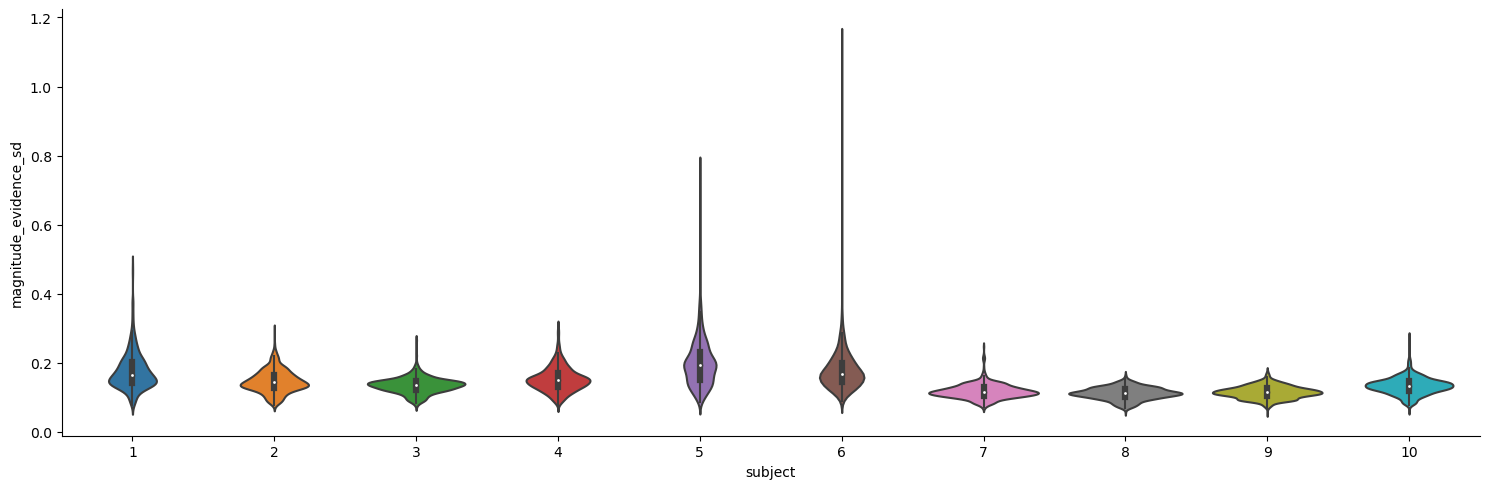

In [ ]:
import matplotlib.pyplot as plt
sns.catplot(x='subject', y='magnitude_evidence_sd', data=idata.posterior['magnitude_evidence_sd'].to_dataframe().reset_index(), aspect=3, kind='violin')
# plt.ylim(0, 2)

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_29972/1850640687.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(idata.posterior['magnitude_evidence_sd_mu'])
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_29972/1850640687.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.dist

<Axes: xlabel='magnitude_prior_sd_mu', ylabel='Density'>

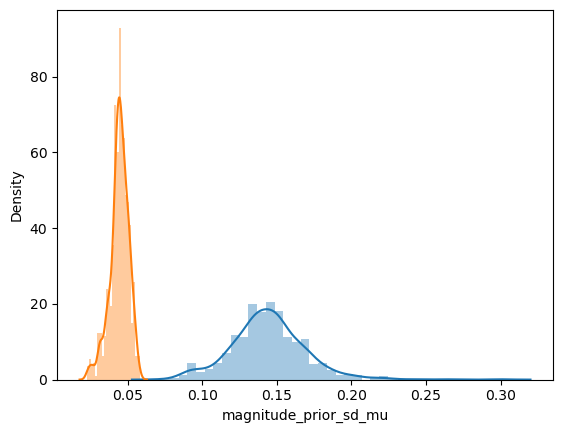

In [ ]:
sns.distplot(idata.posterior['magnitude_evidence_sd_mu'])
sns.distplot(idata.posterior['magnitude_prior_sd_mu'])

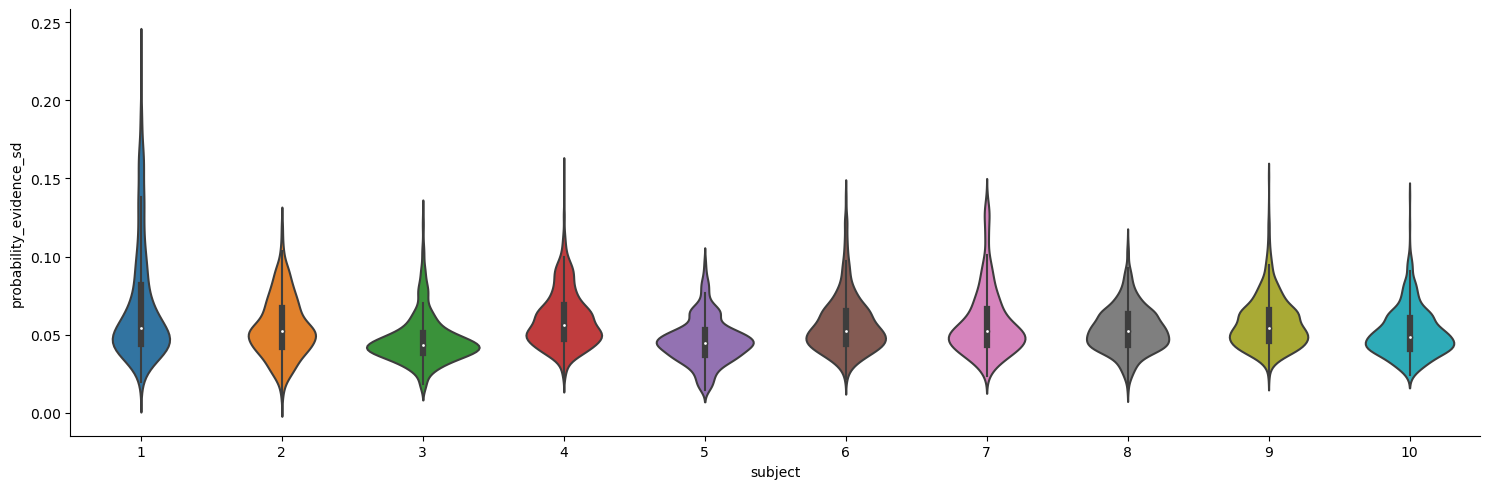

In [ ]:
import matplotlib.pyplot as plt
sns.catplot(x='subject', y='probability_evidence_sd', data=idata.posterior['probability_evidence_sd'].to_dataframe().reset_index(), aspect=3, kind='violin')
# plt.ylim(0, 2)

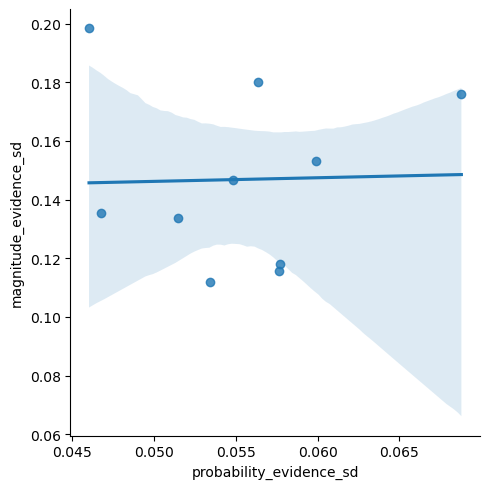

In [ ]:
prob_evidence_sd = idata.posterior['probability_evidence_sd'].to_dataframe()
mag_evidence_sd = idata.posterior['magnitude_evidence_sd'].to_dataframe()

evidence_sd = prob_evidence_sd.join(mag_evidence_sd)


sns.lmplot(x='probability_evidence_sd', y='magnitude_evidence_sd', data=evidence_sd.groupby(['subject']).mean().reset_index())